## Research Question 1: Visual

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
merged_df = pd.read_csv("merged_df.csv")

In [4]:
merged_df.head()

,value,savings,description_doge,total_obligation,award_amount,link,fain_key,date,agency,funding_opportunity_goals,total_obligated_amount,federal_action_obligation,non_federal_funding_amount,action_date,action_date_fiscal_year,awarding_agency_name,awarding_sub_agency_name,funding_office_name,recipient_name,recipient_parent_name,primary_place_of_performance_scope,primary_place_of_performance_country_code,primary_place_of_performance_country_name,primary_place_of_performance_state_name,cfda_title,business_types_description,action_type_description,sector
0,34998729.0,12993908.0,USAID¿S RESEARCH FOR SCALABLE SOLUTIONS (R4S) ...,22004821.0,0.0,https://usaspending.gov/award/ASST_NON_7200AA1...,7200AA19CA00041,3/1/2025,USAID,NaN,22004821.0,0.0,0.0,2023-11-01,2024.0,Agency for International Development,Agency for International Development,USAID M/OAA,FAMILY HEALTH INTERNATIONAL,NaN,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE FOR PROGRAMS OVERSEAS,NONPROFIT WITH 501C3 IRS STATUS (OTHER THAN AN...,REVISION,International Development
1,34998729.0,12993908.0,USAID¿S RESEARCH FOR SCALABLE SOLUTIONS (R4S) ...,22004821.0,50000.0,https://usaspending.gov/award/ASST_NON_7200AA1...,7200AA19CA00041,3/1/2025,USAID,NaN,22004821.0,50000.0,0.0,2024-07-17,2024.0,Agency for International Development,Agency for International Development,USAID M/OAA,FAMILY HEALTH INTERNATIONAL,NaN,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE FOR PROGRAMS OVERSEAS,NONPROFIT WITH 501C3 IRS STATUS (OTHER THAN AN...,CONTINUATION,International Development
2,34722274.0,9273274.0,TO PROVIDE SUPPORT FOR “FAMILY PLANNING AND RE...,25449000.0,0.0,https://usaspending.gov/award/ASST_NON_7200AA2...,7200AA20CA00016,3/1/2025,USAID,ORACLE.SQL.CLOB@736008DE,25449000.0,0.0,0.0,2020-09-30,2020.0,Agency for International Development,Agency for International Development,USAID GH,FAMILY HEALTH INTERNATIONAL,FAMILY HEALTH INTERNATIONAL,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE FOR PROGRAMS OVERSEAS,NONPROFIT WITH 501C3 IRS STATUS (OTHER THAN AN...,REVISION,International Development
3,34722274.0,9273274.0,TO PROVIDE SUPPORT FOR “FAMILY PLANNING AND RE...,25449000.0,0.0,https://usaspending.gov/award/ASST_NON_7200AA2...,7200AA20CA00016,3/1/2025,USAID,ORACLE.SQL.CLOB@736008DE,25449000.0,0.0,0.0,2021-02-21,2021.0,Agency for International Development,Agency for International Development,USAID GH,FAMILY HEALTH INTERNATIONAL,FAMILY HEALTH INTERNATIONAL,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE FOR PROGRAMS OVERSEAS,NONPROFIT WITH 501C3 IRS STATUS (OTHER THAN AN...,REVISION,International Development
4,140000000.0,73943882.0,THE MICROBICIDE 2021 INTRODUCTION AND ACCESS P...,66056118.0,0.0,https://usaspending.gov/award/ASST_NON_7200AA2...,7200AA21CA00011,3/1/2025,USAID,NOT APPLICABLE,66056118.0,0.0,0.0,2021-11-09,2022.0,Agency for International Development,Agency for International Development,USAID M/OAA,FAMILY HEALTH INTERNATIONAL,FAMILY HEALTH INTERNATIONAL,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE FOR PROGRAMS OVERSEAS,NONPROFIT WITH 501C3 IRS STATUS (OTHER THAN AN...,REVISION,International Development


In [5]:
# Distribution of savings

merged_df['log_savings'] = np.log(merged_df['savings'])

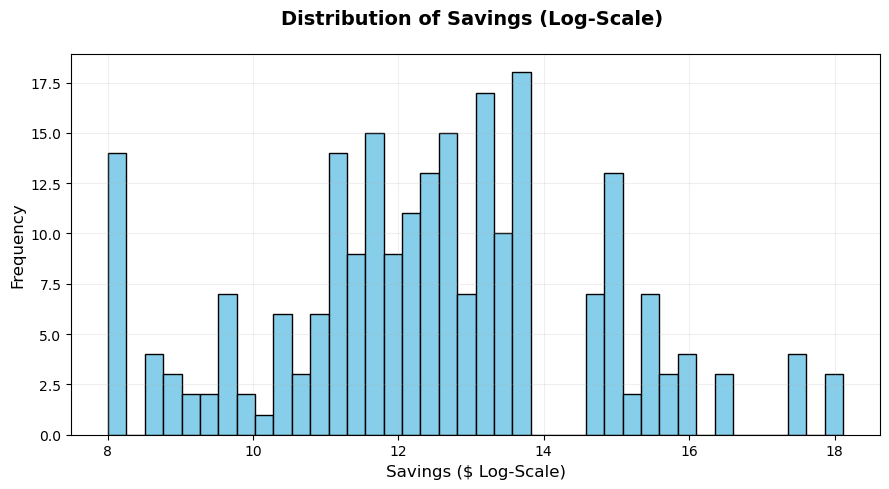

In [6]:
plt.figure(figsize=(9,5))
plt.hist(
    merged_df['log_savings'],
    bins=40,
    edgecolor='black',  
    alpha=1,
    color='skyblue'
)
plt.title("Distribution of Savings (Log-Scale) \n", fontsize=14, fontweight='bold')
plt.xlabel("Savings ($ Log-Scale)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(alpha=0.2)     # light grid
plt.tight_layout()
plt.show()

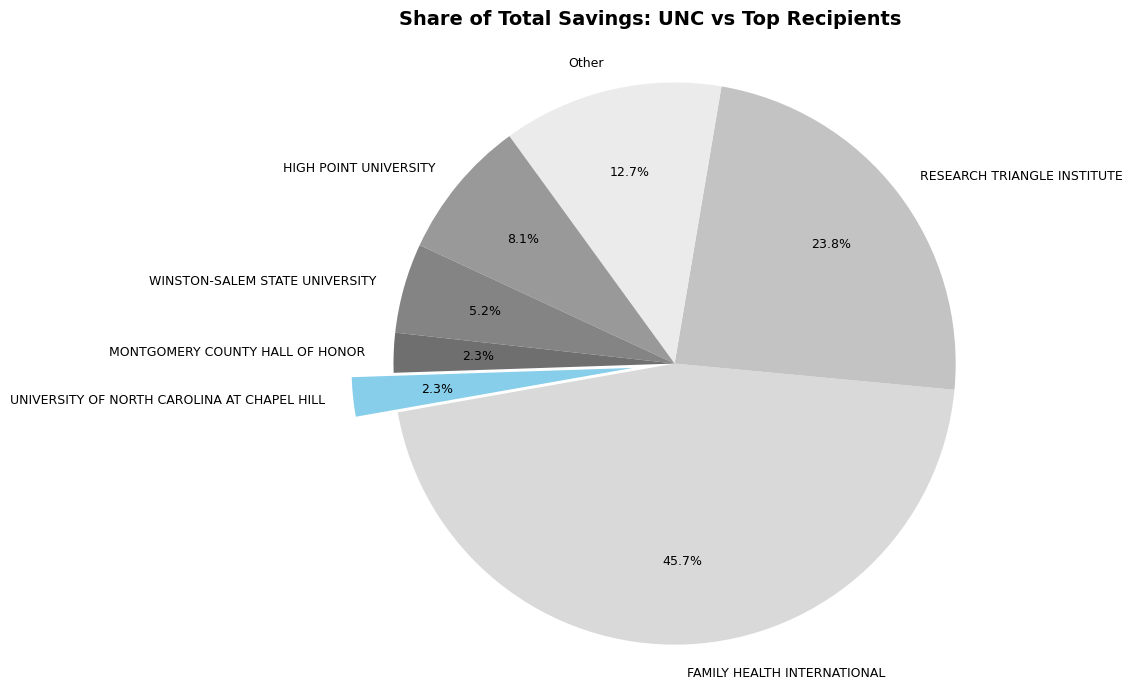

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----- 1. Total savings by recipient -----
recipient_totals_all = (
    merged_df
    .groupby("recipient_name", dropna=False)["savings"]
    .sum()
)

unc_name = "UNIVERSITY OF NORTH CAROLINA AT CHAPEL HILL"

if unc_name not in recipient_totals_all.index:
    raise ValueError("UNC Chapel Hill not found in dataset.")

unc_value = recipient_totals_all.loc[unc_name]

# ----- 2. Top 5 non-UNC -----
others = recipient_totals_all.drop(index=unc_name).sort_values(ascending=False)
top5 = others.head(5)
other_value = others.iloc[5:].sum()

# ----- 3. Assemble categories: UNC + Top5 + Other -----
labels = [unc_name] + list(top5.index) + ["Other"]
sizes  = [unc_value] + list(top5.values) + [other_value]

# ----- 4. Sort slices largest → smallest (but keep UNC recognized later) -----
pairs = sorted(zip(labels, sizes), key=lambda x: x[1], reverse=True)
labels_sorted, sizes_sorted = zip(*pairs)

# ----- 5. Grayscale by size (bigger slice = darker) -----
ranks = np.argsort(-np.array(sizes_sorted))  # rank slices by size
grey_levels = np.linspace(0.85, 0.35, len(sizes_sorted))  # light → darker
grey_shades = grey_levels[ranks]

colors = []
for i, lab in enumerate(labels_sorted):
    if lab == unc_name:
        colors.append("skyblue")       # UNC highlighted
    else:
        colors.append((grey_shades[i], grey_shades[i], grey_shades[i]))

# Make "Other" the lightest grey
for i, lab in enumerate(labels_sorted):
    if lab == "Other":
        colors[i] = (0.92, 0.92, 0.92)

# ----- 6. PUT THE 45% SLICE ON THE RIGHT -----
# Use startangle=0 → first slice begins at 3 o’clock (right side)
# Since slices are sorted largest-first, this places the biggest slice on the right.
start_angle = -170

explode = [0.15 if lab == unc_name else 0 for lab in labels_sorted]

plt.figure(figsize=(10, 7))

plt.pie(
    sizes_sorted,
    labels=labels_sorted,
    colors=colors,
    explode = explode,
    autopct='%1.1f%%',
    startangle=start_angle,
    pctdistance=0.7,
    textprops={'fontsize': 9}
)

plt.title("Share of Total Savings: UNC vs Top Recipients \n",
          fontsize=14, fontweight='bold')

plt.axis('equal')
plt.tight_layout()
plt.show()

## Research Question 2 (Only models are here)

In [8]:
merged_copy= merged_df.copy()

In [9]:
merged_copy = merged_copy.drop(columns = ['link', 'date', 'funding_opportunity_goals', 
                            'total_obligation', 'action_date', 'primary_place_of_performance_country_code', 
                            'primary_place_of_performance_country_name', 'primary_place_of_performance_state_name', 
                            'federal_action_obligation', 'non_federal_funding_amount'])

In [10]:
merged_copy.columns

Index(['value', 'savings', 'description_doge', 'award_amount', 'fain_key',
       'agency', 'total_obligated_amount', 'action_date_fiscal_year',
       'awarding_agency_name', 'awarding_sub_agency_name',
       'funding_office_name', 'recipient_name', 'recipient_parent_name',
       'primary_place_of_performance_scope', 'cfda_title',
       'business_types_description', 'action_type_description', 'sector',
       'log_savings'],
      dtype='object')

In [11]:
unc_df = (
    merged_copy[merged_copy['recipient_parent_name'] == 'THE UNIVERSITY OF NORTH CAROLINA']
    .sort_values(by='savings', ascending=False)
)
unc_df.head()

,value,savings,description_doge,award_amount,fain_key,agency,total_obligated_amount,action_date_fiscal_year,awarding_agency_name,awarding_sub_agency_name,funding_office_name,recipient_name,recipient_parent_name,primary_place_of_performance_scope,cfda_title,business_types_description,action_type_description,sector,log_savings
231,4228801.0,3092663.0,WINSTON-SALEM TEACH TQP RESIDENCY PROGRAM,698034.0,S336S220071,Department Of Education,2534784.0,2023.0,Department of Education,Department of Education,OFC OF ELEMENTARY AND SECONDARY EDU,WINSTON-SALEM STATE UNIVERSITY,THE UNIVERSITY OF NORTH CAROLINA,SINGLE ZIP CODE,TEACHER QUALITY PARTNERSHIP GRANTS,PUBLIC/STATE CONTROLLED INSTITUTION OF HIGHER ...,CONTINUATION,Education,14.944543
230,4228801.0,3092663.0,WINSTON-SALEM TEACH TQP RESIDENCY PROGRAM,114424.0,S336S220071,Department Of Education,2534784.0,2023.0,Department of Education,Department of Education,OFC OF ELEMENTARY AND SECONDARY EDU,WINSTON-SALEM STATE UNIVERSITY,THE UNIVERSITY OF NORTH CAROLINA,SINGLE ZIP CODE,TEACHER QUALITY PARTNERSHIP GRANTS,PUBLIC/STATE CONTROLLED INSTITUTION OF HIGHER ...,REVISION,Education,14.944543
229,4228801.0,3092663.0,WINSTON-SALEM TEACH TQP RESIDENCY PROGRAM,372107.0,S336S220071,Department Of Education,2534784.0,2022.0,Department of Education,Department of Education,OFC OF ELEMENTARY AND SECONDARY EDU,WINSTON-SALEM STATE UNIVERSITY,THE UNIVERSITY OF NORTH CAROLINA,SINGLE ZIP CODE,TEACHER QUALITY PARTNERSHIP GRANTS,PUBLIC/STATE CONTROLLED INSTITUTION OF HIGHER ...,REVISION,Education,14.944543
228,4228801.0,3092663.0,WINSTON-SALEM TEACH TQP RESIDENCY PROGRAM,340895.0,S336S220071,Department Of Education,2534784.0,2022.0,Department of Education,Department of Education,OFC OF ELEMENTARY AND SECONDARY EDU,WINSTON-SALEM STATE UNIVERSITY,THE UNIVERSITY OF NORTH CAROLINA,SINGLE ZIP CODE,TEACHER QUALITY PARTNERSHIP GRANTS,PUBLIC/STATE CONTROLLED INSTITUTION OF HIGHER ...,NEW,Education,14.944543
34,4228801.0,3092662.6,WINSTON-SALEM TEACH TQP RESIDENCY PROGRAM,340895.0,S336S220071,Department Of Education,2534784.0,2022.0,Department of Education,Department of Education,OFC OF ELEMENTARY AND SECONDARY EDU,WINSTON-SALEM STATE UNIVERSITY,THE UNIVERSITY OF NORTH CAROLINA,SINGLE ZIP CODE,TEACHER QUALITY PARTNERSHIP GRANTS,PUBLIC/STATE CONTROLLED INSTITUTION OF HIGHER ...,NEW,Education,14.944543


In [12]:
unc_df.shape

(83, 19)

## Summary of EDA:  
1_ Education receives many awards (size is to be determined)
Hypothesis: cuts might be concentrated in fewer large projects, not spread evenly.  

2_ Massive total_Savings: microbicide program, USAID projects, big education residency programs
That suggests heavy vulnerability of specific types of programs.    

3_ Major role of USAID and International Development. USAID rarely funds domestic education. so why?

4_ Increasing numbers of awards

## Research Question 2: Which types of UNC projects are at highest risk of experiencing large federal funding cuts?

Why this matters (for UNC stakeholders):
1. Helps research offices identify vulnerable grants
2. Guides diversification of funding streams
4. Allows departments to anticipate reduced student support, RA positions, or research capacity
5. Helps leadership protect priority areas

Target variable: define binary outcome using existing "savings"    
In this analysis, high risk refers to UNC projects that experienced larger-than-typical federal funding cuts based on their recorded “savings” amounts. Because savings is a continuous value, we converted it into a binary category to support classification.
Specifically, we labeled a project as high risk if its savings amount was greater than or equal to the median savings among all UNC projects in our dataset. Projects below the median were labeled as low risk.
This approach defines “high risk” as the group of projects that historically experienced disproportionately large funding reductions, enabling us to model vulnerability using classification techniques rather than predicting exact dollar amounts.

Models: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting   
Performance metrics: accuracy, predcidion/recall, ROC-AUC

Possible Stakeholder Interpretation:
1. Projects funded by specific agencies (e.g., USAID, Department of Education) show higher probability of large cuts
2. Projects in certain sectors (e.g., International Development) are at elevated risk
3. Cuts have increased in recent fiscal years—future UNC grants may face increasing risk
4. Programs tied to student development may be disproportionately impacted

BASIC QUESTION: Will this UNC project be high-risk of getting cut or not?

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [14]:
unc_df.columns

Index(['value', 'savings', 'description_doge', 'award_amount', 'fain_key',
       'agency', 'total_obligated_amount', 'action_date_fiscal_year',
       'awarding_agency_name', 'awarding_sub_agency_name',
       'funding_office_name', 'recipient_name', 'recipient_parent_name',
       'primary_place_of_performance_scope', 'cfda_title',
       'business_types_description', 'action_type_description', 'sector',
       'log_savings'],
      dtype='object')

In [15]:
# ------------------------------------------------
# -1) Subset to UNC and define high_risk
# ------------------------------------------------
unc = merged_copy[merged_copy['recipient_parent_name'] == 'THE UNIVERSITY OF NORTH CAROLINA'].copy()
median_savings = unc['savings'].median()
unc['high_risk'] = (unc['savings'] >= median_savings).astype(int)
print("Median savings used as high-risk threshold:", median_savings)

Median savings used as high-risk threshold: 216340.77


In [16]:
import warnings
warnings.filterwarnings("ignore")

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ------------------------------------------------
# 0) Features and target (assuming `unc` and `high_risk` already defined)
#    and you have REMOVED description_doge from features.
# ------------------------------------------------
features = [
    'agency',
    'awarding_agency_name',
    'awarding_sub_agency_name',
    'funding_office_name',
    'cfda_title',
    'business_types_description',
    'action_type_description',
    'sector',
    'primary_place_of_performance_scope',
    'award_amount',
    'total_obligated_amount',
    'action_date_fiscal_year'
]

X = unc[features].copy()
y = unc['high_risk'].copy()

# treat fiscal year as categorical
X['action_date_fiscal_year'] = X['action_date_fiscal_year'].astype(str)

categorical = [
    'agency',
    'awarding_agency_name',
    'awarding_sub_agency_name',
    'funding_office_name',
    'cfda_title',
    'business_types_description',
    'action_type_description',
    'sector',
    'primary_place_of_performance_scope',
    'action_date_fiscal_year'
]

numeric = [
    'award_amount',
    'total_obligated_amount'
]

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', 'passthrough', numeric)
    ]
)

In [18]:
from sklearn.model_selection import cross_val_score

def test_params(model_name, estimator, param_list):
    results = []
    for params in param_list:
        estimator.set_params(**params)
        pipe = Pipeline([
            ('preprocess', preprocess),
            ('model', estimator)
        ])
        scores = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc')
        results.append({
            'params': params,
            'mean_auc': scores.mean(),
            'std_auc': scores.std()
        })
    best = max(results, key=lambda x: x['mean_auc'])
    print(f"Best for {model_name}:", best)
    return best

results_list = []

In [19]:
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(max_iter=1000)

log_param_list = [
    {'C': 0.01},
    {'C': 0.1},
    {'C': 1.0},
    {'C': 10.0}
]

best_log = test_params("Logistic Regression", log_clf, log_param_list)
results_list.append(["Logistic Regression", best_log['params'], best_log['mean_auc'], best_log['std_auc']])

Best for Logistic Regression: {'params': {'C': 0.01}, 'mean_auc': 0.7954861111111111, 'std_auc': 0.26220313166147813}


In [20]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)

tree_param_list = [
    {'max_depth': 2},
    {'max_depth': 3},
    {'max_depth': 4},
    {'max_depth': 5}
]

best_tree = test_params("Decision Tree", tree_clf, tree_param_list)
results_list.append(["Decision Tree", best_tree['params'], best_tree['mean_auc'], best_tree['std_auc']])

Best for Decision Tree: {'params': {'max_depth': 2}, 'mean_auc': 0.8111111111111111, 'std_auc': 0.2393728946978947}


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)

rf_param_list = [
    {'max_depth': 3, 'n_estimators': 100},
    {'max_depth': 5, 'n_estimators': 100},
    {'max_depth': 5, 'n_estimators': 200},
]

best_rf = test_params("Random Forest", rf_clf, rf_param_list)
results_list.append(["Random Forest", best_rf['params'], best_rf['mean_auc'], best_rf['std_auc']])

Best for Random Forest: {'params': {'max_depth': 3, 'n_estimators': 100}, 'mean_auc': 0.836111111111111, 'std_auc': 0.23527630197621888}


In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(random_state=42)

gb_param_list = [
    {'max_depth': 2, 'learning_rate': 0.05},
    {'max_depth': 3, 'learning_rate': 0.05},
    {'max_depth': 3, 'learning_rate': 0.1}
]

best_gb = test_params("Gradient Boosting", gb_clf, gb_param_list)
results_list.append(["Gradient Boosting", best_gb['params'], best_gb['mean_auc'], best_gb['std_auc']])

Best for Gradient Boosting: {'params': {'max_depth': 2, 'learning_rate': 0.05}, 'mean_auc': 0.8527777777777779, 'std_auc': 0.1454956407645311}


In [23]:
results_df = pd.DataFrame(results_list, columns=["Model", "Best_Params", "Mean_AUC", "Std_AUC"])
results_df

,Model,Best_Params,Mean_AUC,Std_AUC
0,Logistic Regression,{'C': 0.01},0.795486,0.262203
1,Decision Tree,{'max_depth': 2},0.811111,0.239373
2,Random Forest,"{'max_depth': 3, 'n_estimators': 100}",0.836111,0.235276
3,Gradient Boosting,"{'max_depth': 2, 'learning_rate': 0.05}",0.852778,0.145496


In [24]:
print("Dataset shape:", X.shape)
print("\nClass distribution (high_risk):")
print(y.value_counts(normalize=True))

Dataset shape: (83, 12)

Class distribution (high_risk):
high_risk
1    0.518072
0    0.481928
Name: proportion, dtype: float64
